In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import rankdata
import numpy as np
from collections import Counter, defaultdict
import os
from surprise import accuracy, Dataset, SVD, Reader
from surprise.model_selection import train_test_split
from surprise.model_selection import cross_validate

In [3]:
class CBFEngine:
    def __init__(self, data_path='data/cbf_df.csv', ratings_count_path='data/movies_ratings_count.csv'):
        self.df_cbf = pd.read_csv(data_path)

        lista_compilado = self.df_cbf['geral'].tolist()

        cvec = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=1, max_df=.85)
        sf = cvec.fit_transform(lista_compilado)

        transformer = TfidfTransformer()
        tfidf_matrix = transformer.fit_transform(sf)

        self.cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

        df_ratings_count = pd.read_csv(ratings_count_path)
        list_ratings_count = np.array(df_ratings_count.loc[:, 'count_ratings'].to_list())
        log_ratings = np.log1p(list_ratings_count)
        self.pop_score = (log_ratings - log_ratings.min()) / (log_ratings.max() - log_ratings.min())

    def recomendar_filmes_perfil(self, user_id, n_recomendacoes=50, threshold=4.0,df_traing_path='data_spliting_hybrid/training.csv'):
        df_traing = pd.read_csv(df_traing_path)

        df_user = df_traing.loc[df_traing['userId'] == user_id]
        df_user = df_user.loc[df_user['rating'] >= threshold]
        
        list_id_movies = df_user['movieId'].to_list()

        ### Pega os indices do filmes dataset de filme
        indices_usuario = self.df_cbf[self.df_cbf['movie_id'].isin(list_id_movies)].index.tolist()

        if not indices_usuario:
            return pd.DataFrame()

        n_filmes = self.cosine_sim.shape[0]

        # ### np.maximum
        # # Recomenda se o filme é similar a PELO MENOS UM seed.
        # # Problema: um único seed pode dominar toda a recomendação.
        # score_acumulado = np.zeros(n_filmes)
        # for idx in indices_usuario:
        ''' 
            score_acumulado    = [0.9, 0.2, 0.5]
            sim_scores_filme   = [0.3, 0.8, 0.5]

            resultado          = [0.9, 0.8, 0.5]  # pega o maior em cada posição
        '''
        #     sim_scores_filme = self.cosine_sim[idx]
        #     score_acumulado = np.maximum(score_acumulado, sim_scores_filme)
        # sim_scores_total = score_acumulado

        ### Reciprocal Rank Fusion (RRF)
        k_rrf = 60
        score_rrf = np.zeros(n_filmes)
        for idx in indices_usuario:
            ranking = np.argsort(self.cosine_sim[idx])[::-1]
            for rank, filme_idx in enumerate(ranking):
                score_rrf[filme_idx] += 1 / (rank + k_rrf)

        sim_scores_total = score_rrf

        sim_norm = rankdata(sim_scores_total) / len(sim_scores_total)
        pop_norm = rankdata(self.pop_score) / len(self.pop_score)

        peso_conteudo = 0.9
        peso_pop = 0.1
        score_hibrido = (sim_norm * peso_conteudo) + (pop_norm * peso_pop)

        sim_scores = list(enumerate(score_hibrido))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores_filtrados = [s for s in sim_scores if s[0] not in indices_usuario]

        top_sim_scores = sim_scores_filtrados[:n_recomendacoes]
        filme_indices = [i[0] for i in top_sim_scores]

        recomendacoes = self.df_cbf.iloc[filme_indices][['movie_id', 'title']].copy()
        recomendacoes['score_recomendacao'] = [i[1] for i in top_sim_scores]

        return recomendacoes

    def verifica_relevantes(self, user_id, recomendacoes, threshold=4.0,df_testing_path='data_spliting_hybrid/testing.csv'):
        df_testing = pd.read_csv(df_testing_path)
        recomendacoes = recomendacoes.loc[:, 'movie_id'].tolist()
        filmes_user_testing = df_testing.loc[
            (df_testing['userId'] == user_id) & (df_testing['rating'] >= threshold)
        ]
        total = pd.Series(recomendacoes).isin(filmes_user_testing['movieId']).sum()
        print(f'O total de filmes para o {user_id} relevantes é de: {total}')
        return total

    def validar_modelo_completo(self, df_test, k=10, threshold=4.0,df_train_path='data_spliting_hybrid/training.csv'):
        df_test_filtrado = df_test[df_test['rating'] >= threshold]
        usuarios_no_teste = df_test_filtrado['userId'].unique()
        df_train = pd.read_csv(df_train_path)

        total_precision = 0
        total_recall = 0
        contagem_usuarios = 0
        resultados_por_usuario = []

        for user_id in usuarios_no_teste:
            filmes_reais = set(df_test_filtrado[df_test_filtrado['userId'] == user_id]['movieId'])

            if len(filmes_reais) < 10:
                continue

            rec_df = self.recomendar_filmes_perfil(user_id, n_recomendacoes=k, threshold=threshold)

            if rec_df.empty:
                continue

            filmes_recomendados = set(rec_df['movie_id'])

            hits = len(filmes_recomendados.intersection(filmes_reais))

            precision_user = hits / k
            recall_user = hits / len(filmes_reais)

            total_precision += precision_user
            total_recall += recall_user
            contagem_usuarios += 1

            filmes_assistidos = df_train[
                (df_train['userId'] == user_id) & (df_train['rating'] >= threshold)
            ]['movieId'].tolist()

            resultados_por_usuario.append({
                'user_id': user_id,
                'precision': precision_user,
                'recall': recall_user,
                'hits': hits,
                'filmes_recomendados': rec_df.copy(),
                'filmes_assistidos': filmes_assistidos,
                'filmes_teste': list(filmes_reais),
            })

        metricas_finais = {
            'Mean Precision@K': total_precision / contagem_usuarios,
            'Mean Recall@K': total_recall / contagem_usuarios,
            'Usuarios Avaliados': contagem_usuarios
        }

        return metricas_finais, resultados_por_usuario

    def exibir_top_usuarios_por_precisao(self, resultados_por_usuario, top_n=10):
        top_usuarios = sorted(resultados_por_usuario, key=lambda x: x['precision'], reverse=True)[:top_n]

        for rank, user_data in enumerate(top_usuarios, start=1):
            user_id               = user_data['user_id']
            precision             = user_data['precision']
            recall                = user_data['recall']
            hits                  = user_data['hits']
            rec_df                = user_data['filmes_recomendados']
            filmes_assistidos_ids = user_data['filmes_assistidos']
            filmes_teste_ids      = set(user_data['filmes_teste'])

            print(f"\n{'='*75}")
            print(f"  TOP {rank:>2} | Usuário ID: {user_id} | Precision@10: {precision:.1%} | Recall@10: {recall:.1%} | Hits: {hits}")
            print(f"{'='*75}")

            assistidos_df = self.df_cbf[self.df_cbf['movie_id'].isin(filmes_assistidos_ids)][['movie_id', 'title']]
            print(f"\n  [FILMES ASSISTIDOS - TREINO]  ({len(assistidos_df)} filmes)")
            print(f"  {'-'*60}")
            for _, row in assistidos_df.iterrows():
                print(f"    {row['movie_id']:>7}  {row['title']}")

            teste_df = self.df_cbf[self.df_cbf['movie_id'].isin(filmes_teste_ids)][['movie_id', 'title']]
            print(f"\n  [FILMES DO TESTE - GABARITO]  ({len(teste_df)} filmes)")
            print(f"  {'-'*60}")
            for _, row in teste_df.iterrows():
                print(f"    {row['movie_id']:>7}  {row['title']}")

            indices_assistidos = self.df_cbf[self.df_cbf['movie_id'].isin(filmes_assistidos_ids)].index.tolist()
            indices_rec        = self.df_cbf[self.df_cbf['movie_id'].isin(rec_df['movie_id'])].index.tolist()

            score_por_idx = dict(zip(indices_rec, rec_df['score_recomendacao'].tolist()))

            print(f"\n  [FILMES RECOMENDADOS + VETORES DE SIMILARIDADE]")
            print(f"  (similaridade cosseno em relação aos {len(indices_assistidos)} filmes do perfil)")
            print(f"  {'-'*75}")
            print(f"  {'#':>2}  {'Título':<50}  {'Score':>7}  {'Sim Média':>9}  {'Sim Máx':>8}  {'Hit?':>5}")
            print(f"  {'-'*75}")

            for pos, (idx_rec, (_, row)) in enumerate(zip(indices_rec, rec_df.iterrows()), start=1):
                if indices_assistidos:
                    sim_vec = self.cosine_sim[idx_rec][indices_assistidos]
                    sim_med = float(sim_vec.mean())
                    sim_max = float(sim_vec.max())
                else:
                    sim_med = sim_max = 0.0

                hit_marker = ' HIT' if row['movie_id'] in filmes_teste_ids else '    '
                titulo = str(row['title'])[:50]
                print(f"  {pos:>2}. {titulo:<50}  {row['score_recomendacao']:>7.4f}  {sim_med:>9.4f}  {sim_max:>8.4f}  {hit_marker}")

        print(f"\n{'='*75}")

    def gerar_estudo_cobertura(self, df_test, ks=[100, 200, 300], threshold=4.0,output_dir='estudo_hibrido',df_train_path='data_spliting_hybrid/training.csv'):
        os.makedirs(output_dir, exist_ok=True)

        df_test_filtrado = df_test[df_test['rating'] >= threshold]

        for k in ks:
            resultados = []

            for user_id in df_test_filtrado['userId'].unique():
                filmes_reais = set(df_test_filtrado[df_test_filtrado['userId'] == user_id]['movieId'])

                rec_df = self.recomendar_filmes_perfil(user_id, n_recomendacoes=k, threshold=threshold,
                                                       df_traing_path=df_train_path)

                if rec_df.empty:
                    continue

                filmes_recomendados = set(rec_df['movie_id'])

                apareceram     = list(filmes_recomendados.intersection(filmes_reais))
                nao_apareceram = list(filmes_reais - filmes_recomendados)
                porcentagem    = round(len(apareceram) / len(filmes_reais) * 100, 2)

                resultados.append({
                    'userId': user_id,
                    'porcentagem_coberta': porcentagem,
                    'filmes_apareceram': apareceram,
                    'filmes_nao_apareceram': nao_apareceram,
                })

            df_resultado = pd.DataFrame(resultados)
            caminho = os.path.join(output_dir, f'cobertura_cbf_k{k}.csv')
            df_resultado.to_csv(caminho, index=False)
            print(f"[K={k}] Salvo em '{caminho}' — {len(df_resultado)} usuários | Cobertura média: {df_resultado['porcentagem_coberta'].mean():.2f}%")

    # ── CBFEngine: RRF sobre universo completo, retorna scores só dos candidatos ──
    def recomendacao_caditatos(self, perfil_ids, candidatos_ids):
        indices_usuario = self.df_cbf[self.df_cbf['movie_id'].isin(perfil_ids)].index.tolist()

        if not indices_usuario:
            return {}

        n_filmes  = self.cosine_sim.shape[0]
        k_rrf     = 60
        score_rrf = np.zeros(n_filmes)
        for idx in indices_usuario:
            ranking = np.argsort(self.cosine_sim[idx])[::-1]
            for rank, filme_idx in enumerate(ranking):
                score_rrf[filme_idx] += 1 / (rank + k_rrf)

        scores = {}
        for movie_id in candidatos_ids:
            idxs = self.df_cbf[self.df_cbf['movie_id'] == movie_id].index
            if len(idxs) > 0:
                scores[movie_id] = float(score_rrf[idxs[0]])
        return scores

    # ── CBFEngine: valida precisão do recomendacao_caditatos() com pool restrito ao teste ──
    def validar_modelo_completo_restrito(self, df_test, k=10, threshold=4.0,
                                         df_train_path='data_spliting_hybrid/training.csv'):
        df_train = pd.read_csv(df_train_path)

        total_precision = 0
        total_recall    = 0
        contagem        = 0
        resultados      = []

        for user_id in df_test['userId'].unique():
            df_user_test   = df_test[df_test['userId'] == user_id]
            candidatos_ids = df_user_test['movieId'].tolist()
            relevantes     = set(df_user_test[df_user_test['rating'] >= threshold]['movieId'])

            if len(relevantes) < 10:
                continue

            perfil_ids = df_train[
                (df_train['userId'] == user_id) & (df_train['rating'] >= threshold)
            ]['movieId'].tolist()

            if not perfil_ids:
                continue

            # remove filmes já assistidos do pool de candidatos
            vistos         = set(df_train[df_train['userId'] == user_id]['movieId'])
            candidatos_ids = [m for m in candidatos_ids if m not in vistos]

            if not candidatos_ids:
                continue

            scores = self.recomendacao_caditatos(perfil_ids, candidatos_ids)

            if not scores:
                continue

            k_efetivo = min(k, len(scores))
            top_k     = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k_efetivo]
            recomendados = set(m for m, _ in top_k)

            hits      = len(recomendados & relevantes)
            precision = hits / k_efetivo
            recall    = hits / len(relevantes)

            total_precision += precision
            total_recall    += recall
            contagem        += 1

            resultados.append({
                'user_id'      : user_id,
                'precision'    : round(precision, 4),
                'recall'       : round(recall, 4),
                'hits'         : hits,
                'n_candidatos' : len(candidatos_ids),
                'n_relevantes' : len(relevantes),
            })

        metricas = {
            'Mean Precision@K'  : round(total_precision / contagem, 4),
            'Mean Recall@K'     : round(total_recall    / contagem, 4),
            'Usuarios Avaliados': contagem,
        }
        return metricas, resultados

cbf = CBFEngine()

In [4]:
df_teste = pd.read_csv('data_spliting_hybrid/testing.csv')
metricas, resultados_usuarios = cbf.validar_modelo_completo(df_teste)
print(metricas)

{'Mean Precision@K': 0.20450704225352126, 'Mean Recall@K': 0.07554736731215538, 'Usuarios Avaliados': 355}


In [5]:
class CFEngine:
    def __init__(self):
        self.reader = Reader(rating_scale=([0.5, 5]))

        self.df_ratings_total = pd.read_csv('ml-latest-small/ratings.csv').drop(columns='timestamp')
        self.df_ratings_traing = pd.read_csv('data_spliting_hybrid/training.csv').drop(columns='timestamp')
        self.df_ratings_testing = pd.read_csv('data_spliting_hybrid/testing.csv').drop(columns='timestamp')
        self.df_movies = pd.read_csv('ml-latest-small/movies.csv')

        self.data_training = Dataset.load_from_df(self.df_ratings_traing, reader=self.reader)
        self.data_testing = Dataset.load_from_df(self.df_ratings_testing, reader=self.reader)
        '''
        O Surprise espera dois formatos diferentes:

        Trainset → um objeto especial interno do Surprise, usado pelo .fit()
        Testset → uma lista de tuplas (uid, iid, nota_real), usado pelo .test()

        '''

        # Treino: build_full_trainset() — constrói um trainset com TODOS os dados do DataFrame
        self.trainset = self.data_training.build_full_trainset()

        # Teste: build_full_trainset().build_testset() — converte para lista de tuplas (uid, iid, nota_real)
        self.testset = self.data_testing.build_full_trainset().build_testset()
                

        self.algo = SVD(    
            n_factors=100,    # dimensões do espaço latente
            n_epochs=20,      # épocas de SGD
            lr_all=0.005,     # learning rate
            random_state=42,
            verbose=True
        )

        self.algo.fit(self.trainset)

        #### Algoítimo aprendido:
        print(f'vetor latente usuário: {self.algo.pu.shape}')
        print(f'vetor latente filme: {self.algo.qi.shape}')
        print(f'vetor de vies de cada usuário: {self.algo.bu.shape}')
        print(f'vetor de vies de cada filme: {self.algo.bi.shape}')

        '''
        Testar o modelo, comparando as predições feitas a partir do treinamento com os dados presentes no teste
        exemplo predição do user 1 no filme 133:
        Prediction(uid=1, iid=1030, r_ui=3.0, est=3.8121344471576815, details={'was_impossible': False}

        '''
        self.predicoes = self.algo.test(self.testset)

        self.filmes_no_treino = set(self.df_ratings_traing['movieId'].unique())
        self.usuarios_no_treino = set(self.df_ratings_traing['userId'].unique())
        

    def recomenda_usuario(self, usuario_id, top_n=10):
        filmes_assistidos = set(self.df_ratings_traing[self.df_ratings_traing['userId'] == usuario_id]['movieId'].tolist())

        ### Implementar aqui nova solução
        todos_os_filmes = set(self.df_movies['movieId'].unique())
        filmes_nao_assistidos = sorted(todos_os_filmes - filmes_assistidos)

        predicoes = []
        for id in filmes_nao_assistidos:
            pred = self.algo.predict(uid=usuario_id, iid=id)
            predicoes.append((id, pred.est))

        arr_sorted = sorted(predicoes, key=lambda x: x[1], reverse=True)

        recomendados = arr_sorted[:top_n]
        ids_recomendados = [movie_id for movie_id, nota in recomendados]

        df_resultado = self.df_movies.loc[self.df_movies['movieId'].isin(ids_recomendados), ['movieId', 'titulo_movie_lens']]

        return df_resultado
    

    def precision_recall_at_k_v2(self, k=10, threshold=4.0):
        """
        Calcula Precision@K e Recall@K chamando recomenda_usuario para cada usuário.
        Um filme é considerado relevante se estiver no teste com rating >= threshold.
        """
        usuarios = self.df_ratings_testing['userId'].unique()

        precisions = {}
        recalls = {}

        for usuario_id in usuarios:
            ids_recomendados = self.recomenda_usuario(usuario_id, top_n=k)['movieId'].tolist()

            filmes_teste_usuario = self.df_ratings_testing[self.df_ratings_testing['userId'] == usuario_id]
            filmes_relevantes_teste = set(
                filmes_teste_usuario[filmes_teste_usuario['rating'] >= threshold]['movieId'].tolist()
            )

            ### se o final não tiver menos de 10 filmes
            if len(filmes_relevantes_teste) < 10:
                continue

            n_rel_top_k = sum(1 for movie_id in ids_recomendados if movie_id in filmes_relevantes_teste)
            n_rel_total = len(filmes_relevantes_teste)

            precisions[usuario_id] = n_rel_top_k / k if k > 0 else 0
            recalls[usuario_id] = n_rel_top_k / n_rel_total if n_rel_total > 0 else 0

        mean_precision = sum(precisions.values()) / len(precisions) if precisions else 0
        mean_recall = sum(recalls.values()) / len(recalls) if recalls else 0

        return mean_precision, mean_recall, precisions, recalls
    

    def accuracy_predictions(self):
        ### Calcualando o RMSE E MEA

        rmse = accuracy.rmse(self.predicoes)

        mae = accuracy.mae(self.predicoes)

        print(rmse)
        print(mae)

    # ── CFEngine: predição SVD normalizada por rank dentro do pool de candidatos ──
    def recomendar_candidatos(self, user_id, candidatos_ids, k=10):
        vistos     = set(self.df_ratings_traing[self.df_ratings_traing['userId'] == user_id]['movieId'])
        candidatos = [m for m in candidatos_ids if m not in vistos]

        if not candidatos:
            return {}

        cf_raw  = {m: self.algo.predict(uid=user_id, iid=m).est for m in candidatos}
        cf_rnks = rankdata([cf_raw[m] for m in candidatos])
        cf_norm = {m: cf_rnks[i] / len(candidatos) for i, m in enumerate(candidatos)}

        k_efetivo = min(k, len(cf_norm))
        top_k     = sorted(cf_norm.items(), key=lambda x: x[1], reverse=True)[:k_efetivo]
        return dict(top_k)

    # ── CFEngine: valida precisão do recomendar_candidatos() com pool restrito ao teste ──
    def validar_modelo_completo_restrito(self, df_test, k=10, threshold=4.0):
        total_precision = 0
        total_recall    = 0
        contagem        = 0
        resultados      = []

        for user_id in df_test['userId'].unique():
            df_user_test   = df_test[df_test['userId'] == user_id]
            candidatos_ids = df_user_test['movieId'].tolist()
            relevantes     = set(df_user_test[df_user_test['rating'] >= threshold]['movieId'])

            if len(relevantes) < 10:
                continue

            scores = self.recomendar_candidatos(user_id, candidatos_ids, k=k)

            if not scores:
                continue

            recomendados = set(scores.keys())
            k_efetivo    = len(recomendados)

            hits      = len(recomendados & relevantes)
            precision = hits / k_efetivo
            recall    = hits / len(relevantes)

            total_precision += precision
            total_recall    += recall
            contagem        += 1

            resultados.append({
                'user_id'      : user_id,
                'precision'    : round(precision, 4),
                'recall'       : round(recall, 4),
                'hits'         : hits,
                'n_candidatos' : len(candidatos_ids),
                'n_relevantes' : len(relevantes),
            })

        metricas = {
            'Mean Precision@K'  : round(total_precision / contagem, 4),
            'Mean Recall@K'     : round(total_recall    / contagem, 4),
            'Usuarios Avaliados': contagem,
        }
        return metricas, resultados

cf_engine= CFEngine()

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
vetor latente usuário: (610, 100)
vetor latente filme: (8536, 100)
vetor de vies de cada usuário: (610,)
vetor de vies de cada filme: (8536,)


In [6]:

# cf_engine.recomenda_usuario(usuario_id=1)
K=10
mean_p, mean_r, precisions, recalls = cf_engine.precision_recall_at_k_v2(k=K, threshold=4.0)


print(f'Mean Precision@{K}: {mean_p:.4f}')
print(f'Mean Recall@{K}:    {mean_r:.4f}')
print(f'Usuários avaliados: {len(precisions)}')

cf_engine.accuracy_predictions()


Mean Precision@10: 0.1223
Mean Recall@10:    0.0380
Usuários avaliados: 355
RMSE: 0.8836
MAE:  0.6786
0.8835689739780118
0.6786146139127753


In [7]:
class HybridEngine:
    def __init__(self, cbf_engine, cf_engine):
        self.cbf = cbf_engine
        self.cf = cf_engine
        self._title_map = dict(zip(self.cbf.df_cbf['movie_id'], self.cbf.df_cbf['title']))

    def recomendar(self, user_id, k_cbf=200, k=10, alpha=0.6, threshold=4.0, df_train_path='data_spliting_hybrid/training.csv'):
        df_train = pd.read_csv(df_train_path)

        cbf_rec = self.cbf.recomendar_filmes_perfil(
            user_id, n_recomendacoes=k_cbf, threshold=threshold, df_traing_path=df_train_path
        )

        if cbf_rec.empty:
            return pd.DataFrame()

        cbf_movie_ids = set(cbf_rec['movie_id'].tolist())

        filmes_assistidos = set(df_train[df_train['userId'] == user_id]['movieId'].tolist())
        filmes_nao_assistidos = [m for m in self.cf.df_movies['movieId'] if m not in filmes_assistidos]

        # CF: normalização global (rank / N_total) sobre todos os filmes não assistidos
        cf_predictions = {
            m: self.cf.algo.predict(uid=user_id, iid=m).est
            for m in filmes_nao_assistidos
        }
        all_ids = list(cf_predictions.keys())
        cf_ranks = rankdata([cf_predictions[m] for m in all_ids])
        N_total = len(all_ids)
        cf_norm_global = {m: cf_ranks[i] / N_total for i, m in enumerate(all_ids)}

        # CBF: normalização local (rank / K)
        cbf_ranks = rankdata(cbf_rec['score_recomendacao'].tolist())
        cbf_norm_local = {
            movie_id: cbf_ranks[i] / k_cbf
            for i, movie_id in enumerate(cbf_rec['movie_id'])
        }

        # Cascade apenas: score híbrido só para os candidatos do CBF
        scores_finais = {}
        for movie_id in cbf_movie_ids:
            if movie_id in filmes_assistidos:
                continue
            cf_n = cf_norm_global.get(movie_id, 0)
            scores_finais[movie_id] = alpha * cbf_norm_local[movie_id] + (1 - alpha) * cf_n

        top_n = sorted(scores_finais.items(), key=lambda x: x[1], reverse=True)[:k]

        rows = [
            {'movie_id': movie_id, 'title': self._title_map.get(movie_id, f'[id={movie_id}]'), 'score_hibrido': score}
            for movie_id, score in top_n
        ]
        return pd.DataFrame(rows)

    def validar_modelo_completo(self, df_test, k=10, k_cbf=200, alpha=0.6, threshold=4.0, df_train_path='data_spliting_hybrid/training.csv'):
        df_test_filtrado = df_test[df_test['rating'] >= threshold]
        usuarios = df_test_filtrado['userId'].unique()

        total_precision = 0
        total_recall = 0
        contagem = 0
        resultados = []

        for user_id in usuarios:
            filmes_reais = set(df_test_filtrado[df_test_filtrado['userId'] == user_id]['movieId'])

            if len(filmes_reais) < 10:
                continue

            rec_df = self.recomendar(
                user_id, k=k, k_cbf=k_cbf, alpha=alpha,
                threshold=threshold, df_train_path=df_train_path
            )
            if rec_df.empty:
                continue

            hits = len(set(rec_df['movie_id']) & filmes_reais)
            precision = hits / k
            recall = hits / len(filmes_reais)

            total_precision += precision
            total_recall += recall
            contagem += 1

            resultados.append({
                'user_id': user_id,
                'precision': precision,
                'recall': recall,
                'hits': hits,
                'filmes_recomendados': rec_df.copy(),
                'filmes_reais': list(filmes_reais),
            })

        metricas = {
            'Mean Precision@K': round(total_precision / contagem, 4),
            'Mean Recall@K': round(total_recall / contagem, 4),
            'Usuarios Avaliados': contagem,
            'Params': {'k_cbf': k_cbf, 'alpha': alpha}
        }
        return metricas, resultados

    def recomendar_restrito(self, user_id, candidatos_ids, df_train, k=10, alpha=0.6, threshold=4.0):
        vistos     = set(df_train[df_train['userId'] == user_id]['movieId'])
        candidatos = [m for m in candidatos_ids if m not in vistos]

        if not candidatos:
            return pd.DataFrame()

        perfil_ids = df_train[
            (df_train['userId'] == user_id) & (df_train['rating'] >= threshold)
        ]['movieId'].tolist()

        cbf_raw = self.cbf.recomendacao_caditatos(perfil_ids, candidatos)
        if not cbf_raw:
            return pd.DataFrame()

        cbf_ids  = list(cbf_raw.keys())
        cbf_rnks = rankdata([cbf_raw[m] for m in cbf_ids])
        cbf_norm = {m: cbf_rnks[i] / len(cbf_ids) for i, m in enumerate(cbf_ids)}

        candidatos_cascade = [m for m in candidatos if m in cbf_norm]
        if not candidatos_cascade:
            return pd.DataFrame()

        cf_raw  = {m: self.cf.algo.predict(uid=user_id, iid=m).est for m in candidatos_cascade}
        cf_rnks = rankdata([cf_raw[m] for m in candidatos_cascade])
        cf_norm = {m: cf_rnks[i] / len(candidatos_cascade) for i, m in enumerate(candidatos_cascade)}

        scores = {
            movie_id: alpha * cbf_norm[movie_id] + (1 - alpha) * cf_norm[movie_id]
            for movie_id in candidatos_cascade
        }

        k_efetivo = min(k, len(scores))
        top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k_efetivo]

        rows = [
            {'movie_id': movie_id, 'title': self._title_map.get(movie_id, f'[id={movie_id}]'), 'score_hibrido': score}
            for movie_id, score in top
        ]
        return pd.DataFrame(rows)

    def validar_restrito(self, df_test, k=10, alpha=0.6, threshold=4.0, df_train_path='data_spliting_hybrid/training.csv'):
        df_train        = pd.read_csv(df_train_path)
        total_precision = 0
        total_recall    = 0
        contagem        = 0
        resultados      = []

        for user_id in df_test['userId'].unique():
            df_user_test = df_test[df_test['userId'] == user_id]
            candidatos   = df_user_test['movieId'].tolist()
            relevantes   = set(df_user_test[df_user_test['rating'] >= threshold]['movieId'])

            if len(relevantes) < 10:
                continue

            rec_df = self.recomendar_restrito(
                user_id, candidatos, df_train,
                k=k, alpha=alpha, threshold=threshold
            )
            if rec_df.empty:
                continue

            k_efetivo = len(rec_df)
            hits      = len(set(rec_df['movie_id']) & relevantes)
            precision = hits / k_efetivo
            recall    = hits / len(relevantes)

            total_precision += precision
            total_recall    += recall
            contagem        += 1

            resultados.append({
                'user_id'            : user_id,
                'precision'          : round(precision, 4),
                'recall'             : round(recall, 4),
                'hits'               : hits,
                'n_candidatos'       : len(candidatos),
                'n_relevantes'       : len(relevantes),
                'filmes_recomendados': rec_df.copy(),
            })

        metricas = {
            'Mean Precision@K': round(total_precision / contagem, 4),
            'Mean Recall@K'   : round(total_recall    / contagem, 4),
            'Usuarios Avaliados': contagem,
            'Params'           : {'k': k, 'alpha': alpha},
        }
        return metricas, resultados


In [8]:
hybrid = HybridEngine(cbf_engine=cbf, cf_engine=cf_engine)


hybrid.recomendar(25)

,movie_id,title,score_hibrido
0,260,Star Wars: Episode IV - A New Hope (1977),0.993463
1,2959,Fight Club (1999),0.989308
2,79132,Inception (2010),0.987836
3,109487,Interstellar (2014),0.978037
4,3793,X-Men (2000),0.976966
5,112852,Guardians of the Galaxy (2014),0.969285
6,541,Blade Runner (1982),0.963463
7,1240,"Terminator, The (1984)",0.962624
8,2640,Superman (1978),0.951754
9,122918,Guardians of the Galaxy 2 (2017),0.943950


In [9]:
df_teste = pd.read_csv('data_spliting_hybrid/testing.csv')

metricas_hibrido, resultados_hibrido = hybrid.validar_modelo_completo(
    df_teste, k=10, k_cbf=200, alpha=0.2
)

metricas_hibrido

{'Mean Precision@K': 0.2358,
 'Mean Recall@K': 0.0827,
 'Usuarios Avaliados': 355,
 'Params': {'k_cbf': 200, 'alpha': 0.2}}

In [10]:
p_cbf  = metricas['Mean Precision@K']
r_cbf  = metricas['Mean Recall@K']
p_cf   = mean_p
r_cf   = mean_r
p_hyb  = metricas_hibrido['Mean Precision@K']
r_hyb  = metricas_hibrido['Mean Recall@K']
params = metricas_hibrido['Params']

print("=" * 58)
print("  COMPARATIVO FINAL — Precision@10 / Recall@10")
print("=" * 58)
print(f"  {'Modelo':<22}  {'Precision@10':>12}  {'Recall@10':>10}")
print(f"  {'-'*52}")
print(f"  {'CBF puro (RRF)':<22}  {p_cbf:>12.4f}  {r_cbf:>10.4f}")
print(f"  {'CF puro (SVD)':<22}  {p_cf:>12.4f}  {r_cf:>10.4f}")
print(f"  {'Híbrido (Cascade)':<22}  {p_hyb:>12.4f}  {r_hyb:>10.4f}")
print("=" * 58)
print(f"  Params híbrido: K={params['k_cbf']}, α={params['alpha']}")
print("=" * 58)

delta_p = (p_hyb - p_cbf) / p_cbf * 100
delta_r = (r_hyb - r_cbf) / r_cbf * 100
print(f"\n  Ganho híbrido vs CBF:  Precision {delta_p:+.1f}%  |  Recall {delta_r:+.1f}%")

  COMPARATIVO FINAL — Precision@10 / Recall@10
  Modelo                  Precision@10   Recall@10
  ----------------------------------------------------
  CBF puro (RRF)                0.2045      0.0755
  CF puro (SVD)                 0.1223      0.0380
  Híbrido (Cascade)             0.2358      0.0827
  Params híbrido: K=200, α=0.2

  Ganho híbrido vs CBF:  Precision +15.3%  |  Recall +9.5%


In [11]:
df_teste = pd.read_csv('data_spliting_hybrid/testing.csv')

metricas_restrito, resultados_restrito = hybrid.validar_restrito(
    df_teste, k=10, alpha=0.2
)

# ── Comparativo ───────────────────────────────────────────────────────────────
p_irr = metricas_hibrido['Mean Precision@K']
r_irr = metricas_hibrido['Mean Recall@K']
p_res = metricas_restrito['Mean Precision@K']
r_res = metricas_restrito['Mean Recall@K']

media_candidatos = np.mean([r['n_candidatos'] for r in resultados_restrito])
media_relevantes = np.mean([r['n_relevantes'] for r in resultados_restrito])

print("=" * 65)
print("  COMPARATIVO: Irrestrito vs Restrito (Candidate Sampling)")
print("=" * 65)
print(f"  {'Modo':<35}  {'Precision@10':>12}  {'Recall@10':>10}")
print(f"  {'-'*61}")
print(f"  {'Híbrido Irrestrito (~9k candidatos)':<35}  {p_irr:>12.4f}  {r_irr:>10.4f}")
print(f"  {'Híbrido Restrito (filmes do teste)':<35}  {p_res:>12.4f}  {r_res:>10.4f}")
print("=" * 65)
print(f"\n  Pool médio por usuário: {media_candidatos:.0f} filmes")
print(f"  Relevantes médios:      {media_relevantes:.0f} filmes")
print(f"  Usuários avaliados:     {metricas_restrito['Usuarios Avaliados']}")

  COMPARATIVO: Irrestrito vs Restrito (Candidate Sampling)
  Modo                                 Precision@10   Recall@10
  -------------------------------------------------------------
  Híbrido Irrestrito (~9k candidatos)        0.2358      0.0827
  Híbrido Restrito (filmes do teste)         0.7856      0.3518

  Pool médio por usuário: 77 filmes
  Relevantes médios:      37 filmes
  Usuários avaliados:     355


In [ ]:
df_teste = pd.read_csv('data_spliting_hybrid/testing.csv')

metricas_cbf_restrito, resultados_cbf_restrito = cbf.validar_modelo_completo_restrito(df_teste)
metricas_cf_restrito,  resultados_cf_restrito  = cf_engine.validar_modelo_completo_restrito(df_teste)

p_cbf_res = metricas_cbf_restrito['Mean Precision@K']
r_cbf_res = metricas_cbf_restrito['Mean Recall@K']
p_cf_res  = metricas_cf_restrito['Mean Precision@K']
r_cf_res  = metricas_cf_restrito['Mean Recall@K']

print("=" * 65)
print("  COMPARATIVO RESTRITO — Precision@10 / Recall@10")
print("=" * 65)
print(f"  {'Modelo':<30}  {'Precision@10':>12}  {'Recall@10':>10}")
print(f"  {'-'*58}")
print(f"  {'CBF Restrito (RRF)':<30}  {p_cbf_res:>12.4f}  {r_cbf_res:>10.4f}")
print(f"  {'CF Restrito (SVD)':<30}  {p_cf_res:>12.4f}  {r_cf_res:>10.4f}")
print(f"  {'Híbrido Restrito':<30}  {p_res:>12.4f}  {r_res:>10.4f}")
print("=" * 65)
print(f"  Usuários avaliados: {metricas_cf_restrito['Usuarios Avaliados']}")

  COMPARATIVO RESTRITO — Precision@10 / Recall@10
  Modelo                          Precision@10   Recall@10
  ----------------------------------------------------------
  CBF Restrito (RRF)                    0.6935      0.3160
  CF Restrito (SVD)                     0.7634      0.3448
  Híbrido Restrito                      0.7856      0.3518
  Usuários avaliados: 355


valor de referência (melhor modelo puro por cenário/métrica):
  Catálogo completo — Precision: FBC (0.2045)  |  Recall: FBC (0.0755)
  Candidatos        — Precision: FC (0.7634)  |  Recall: FC (0.3448)


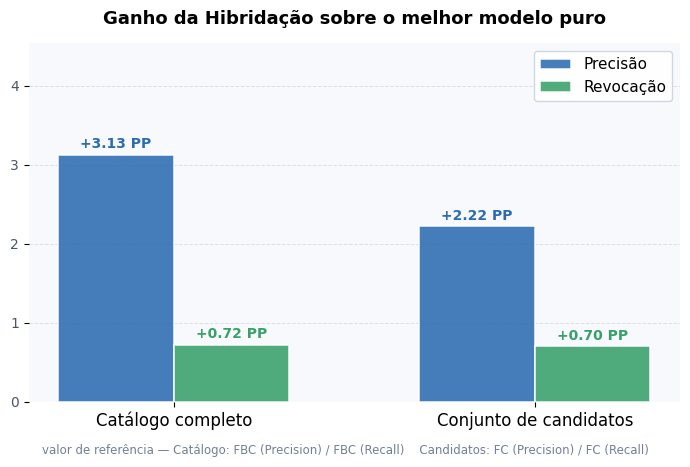

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Melhor modelo puro por cenário/métrica (dinâmico) ───────────────────────
best_p_irr = max(p_cbf,     p_cf)
best_r_irr = max(r_cbf,     r_cf)
best_p_res = max(p_cbf_res, p_cf_res)
best_r_res = max(r_cbf_res, r_cf_res)

label_p_irr = 'FBC' if p_cbf     >= p_cf     else 'FC'
label_r_irr = 'FBC' if r_cbf     >= r_cf     else 'FC'
label_p_res = 'FBC' if p_cbf_res >= p_cf_res else 'FC'
label_r_res = 'FBC' if r_cbf_res >= r_cf_res else 'FC'

print("valor de referência (melhor modelo puro por cenário/métrica):")
print(f"  Catálogo completo — Precision: {label_p_irr} ({best_p_irr:.4f})  |  Recall: {label_r_irr} ({best_r_irr:.4f})")
print(f"  Candidatos        — Precision: {label_p_res} ({best_p_res:.4f})  |  Recall: {label_r_res} ({best_r_res:.4f})")

# ── Ganho ABSOLUTO em pontos percentuais (p.p.) ─────────────────────────────
metricas_plot = {
    'Precisão': [
        (p_hyb - best_p_irr) * 100,
        (p_res - best_p_res) * 100,
    ],
    'Revocação': [
        (r_hyb - best_r_irr) * 100,
        (r_res - best_r_res) * 100,
    ],
}

cenarios = ['Catálogo completo', 'Conjunto de candidatos']
cores    = ["#2B6CB0", '#38A169']

x     = np.arange(len(cenarios))
width = 0.32

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.set_facecolor('#F7F9FC')
ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7, color='#CBD5E0', zorder=0)
ax.set_axisbelow(True)

for i, (metrica, cor) in enumerate(zip(metricas_plot, cores)):
    valores = metricas_plot[metrica]
    bars = ax.bar(x + (i - 0.5) * width, valores, width,
                  label=metrica, color=cor, alpha=0.88,
                  edgecolor='white', linewidth=1.2, zorder=3)
    for bar, v in zip(bars, valores):
        sinal = '+' if v >= 0 else ''
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'{sinal}{v:.2f} PP',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=cor)

rodape = (
    f'valor de referência — Catálogo: FBC (Precision) / FBC (Recall)    '
    f'Candidatos: FC (Precision) / FC (Recall)'
)


ax.set_xticks(x)
ax.set_xticklabels(cenarios, fontsize=12)
ax.set_title('Ganho da Hibridação sobre o melhor modelo puro', fontsize=13, fontweight='bold', pad=14)
ax.set_ylim(0, max(v for vals in metricas_plot.values() for v in vals) * 1.45)
ax.tick_params(axis='y', labelcolor='#4A5568')
ax.legend(fontsize=11, framealpha=0.9, edgecolor='#CBD5E0', loc='upper right')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('comparativo_modelos.pdf', bbox_inches='tight', dpi=300)
plt.savefig('comparativo_modelos.png', bbox_inches='tight', dpi=300)
plt.show()
